# Heart MRI Segmentation — Multi-Model Comparison
### Models: U-Net · ResNet-UNet · SegNet · DeepLabV3+ (with Transformer Attention)

## 1. Install Dependencies

In [ ]:
!pip install nibabel tqdm scikit-learn matplotlib

## 2. Imports

In [ ]:
import os
import numpy as np
import nibabel as nib
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
!rm -rf /content/drive

## 3. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4. Dataset Path

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Task02_Heart/Task02_Heart"

IMG_DIR = os.path.join(DATASET_PATH, "imagesTr")
MASK_DIR = os.path.join(DATASET_PATH, "labelsTr")

print("Images:", len(os.listdir(IMG_DIR)))
print("Masks:",  len(os.listdir(MASK_DIR)))

Images: 21
Masks: 22


## 5. Preprocessing Helpers

In [ ]:
IMG_SIZE = 256

def normalize_image(img):
    img = img.astype(np.float32)
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)
    return img

def resize_slice(slice_img):
    slice_img = tf.image.resize(slice_img[..., np.newaxis], (IMG_SIZE, IMG_SIZE))
    return slice_img.numpy()

## 6. Load .nii.gz Data

In [ ]:
X, Y = [], []
files = sorted(os.listdir(IMG_DIR))
print("Loading dataset...")

for f in tqdm(files):
    if f.startswith('._'):
        continue
    img_path  = os.path.join(IMG_DIR,  f)
    mask_path = os.path.join(MASK_DIR, f)
    img  = nib.load(img_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    for i in range(img.shape[2]):
        img_slice  = normalize_image(img[:, :, i])
        mask_slice = mask[:, :, i]

        img_slice  = resize_slice(img_slice)[:, :, 0]
        mask_slice = resize_slice(mask_slice)[:, :, 0]
        mask_slice = (mask_slice > 0).astype(np.float32)

        X.append(img_slice)
        Y.append(mask_slice)

X = np.expand_dims(np.array(X), axis=-1)
Y = np.expand_dims(np.array(Y), axis=-1)
print("X shape:", X.shape)
print("Y shape:", Y.shape)

Loading dataset...


100%|██████████| 21/21 [00:46<00:00,  2.21s/it]


X shape: (2271, 256, 256, 1)
Y shape: (2271, 256, 256, 1)


## 7. Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (1816, 256, 256, 1)
Test:  (455, 256, 256, 1)


## 8. Shared Loss Functions & Metrics

In [ ]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def compute_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred)
    union        = np.logical_or(y_true,  y_pred)
    union_sum    = np.sum(union)
    return 1.0 if union_sum == 0 else np.sum(intersection) / union_sum

def evaluate_model(model, X_test, y_test, threshold=0.3):
    """Returns dict with dice, iou, accuracy, precision, recall, f1"""
    preds = model.predict(X_test, verbose=0)
    preds_bin = (preds > threshold).astype(np.uint8)

    # Per-image Dice
    dice_scores = []
    iou_scores  = []
    for i in range(len(X_test)):
        yt = y_test[i].flatten()
        yp = preds_bin[i].flatten()
        inter = np.sum(yt * yp)
        denom = np.sum(yt) + np.sum(yp)
        dice_scores.append((2 * inter) / (denom + 1e-8) if denom > 0 else 1.0)
        iou_scores.append(compute_iou(y_test[i], preds_bin[i]))

    # Global pixel-level metrics from confusion matrix
    yt_flat = y_test.flatten()
    yp_flat = preds_bin.flatten()
    cm = confusion_matrix(yt_flat, yp_flat)
    tn, fp, fn, tp = cm.ravel()

    accuracy  = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    results = {
        "dice":      np.mean(dice_scores),
        "iou":       np.mean(iou_scores),
        "accuracy":  accuracy,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "cm":        cm
    }
    return results, preds_bin

---
## 9. Model 1 — U-Net (Original)
Encoder–decoder with skip connections. Your original project model.

In [ ]:
def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(32,  3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32,  3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64,  3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64,  3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(b)

    # Decoder
    u1 = layers.UpSampling2D()(b);  u1 = layers.concatenate([u1, c3])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c4); u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(64,  3, activation='relu', padding='same')(u2)

    u3 = layers.UpSampling2D()(c5); u3 = layers.concatenate([u3, c1])
    c6 = layers.Conv2D(32,  3, activation='relu', padding='same')(u3)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)
    return models.Model(inputs, outputs, name='UNet')

unet_model = build_unet()
unet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                   loss=bce_dice_loss, metrics=[dice_coef])
unet_model.summary()

Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[

 Total params: 1,752,545 (6.69 MB)

 Trainable params: 1,752,545 (6.69 MB)

 Non-trainable params: 0 (0.00 B)

### Train U-Net

In [ ]:
unet_history = unet_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 73s 228ms/step - dice_coef: 0.2053 - loss: 0.8971 - val_dice_coef: 0.5437 - val_loss: 0.4814
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - dice_coef: 0.5348 - loss: 0.4876 - val_dice_coef: 0.5953 - val_loss: 0.4233
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - dice_coef: 0.5151 - loss: 0.5181 - val_dice_coef: 0.7046 - val_loss: 0.3054
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - dice_coef: 0.6892 - loss: 0.3255 - val_dice_coef: 0.7758 - val_loss: 0.2312
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - dice_coef: 0.7652 - loss: 0.2431 - val_dice_coef: 0.8010 - val_loss: 0.2068
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 24s 115ms/step - dice_coef: 0.7826 - loss: 0.2254 - val_dice_coef: 0.8353 - val_loss: 0.1712
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 24s 115ms/step - dice_coef: 0.8285 - loss: 0.1788 - val_dice_coef: 0.8504 - val_loss: 0.1548
Epoch 8/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 24s 115ms/step - dice_coef: 0

### Evaluate U-Net

=== U-Net Results ===
  dice      : 0.9099
  iou       : 0.8742
  accuracy  : 0.9995
  precision : 0.9385
  recall    : 0.9472
  f1        : 0.9429


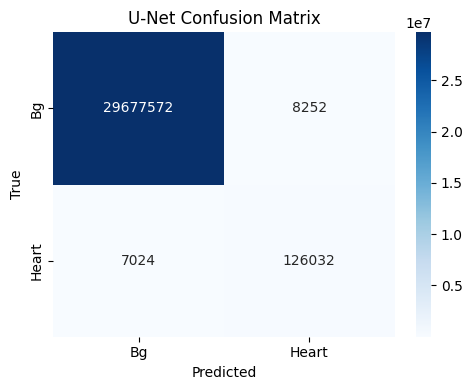

In [ ]:
unet_results, unet_preds = evaluate_model(unet_model, X_test, y_test)
print("=== U-Net Results ===")
for k, v in unet_results.items():
    if k != 'cm':
        print(f"  {k:10s}: {v:.4f}")

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(unet_results['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bg','Heart'], yticklabels=['Bg','Heart'])
plt.title('U-Net Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Visualise U-Net Predictions

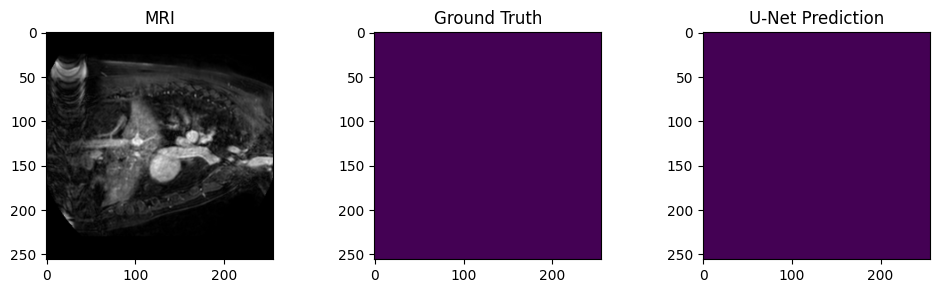

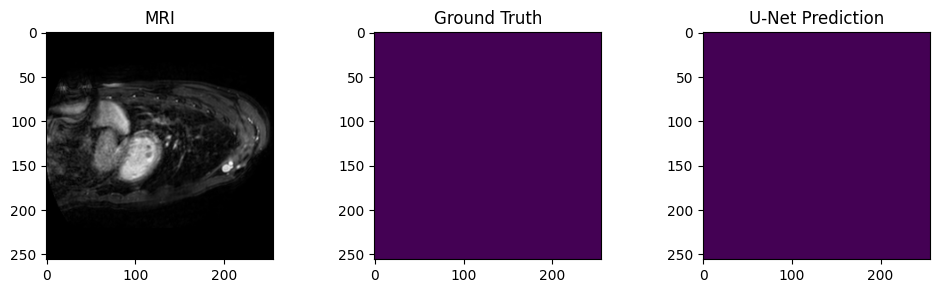

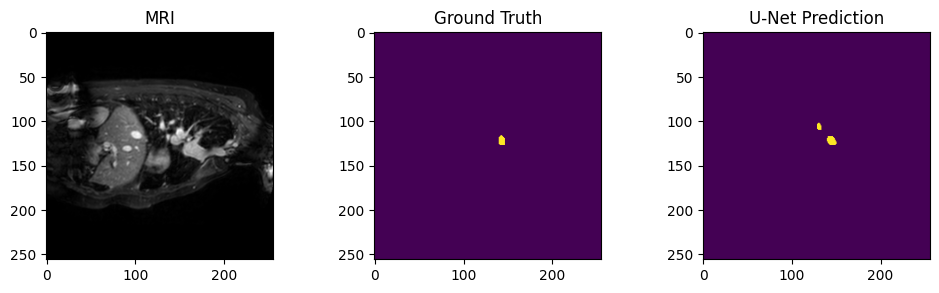

In [ ]:
for i in range(3):
    idx = np.random.randint(0, len(X_test))
    plt.figure(figsize=(10, 3))
    plt.subplot(1,3,1); plt.imshow(X_test[idx].squeeze(), cmap='gray');   plt.title('MRI')
    plt.subplot(1,3,2); plt.imshow(y_test[idx].squeeze());                plt.title('Ground Truth')
    plt.subplot(1,3,3); plt.imshow(unet_preds[idx].squeeze());            plt.title('U-Net Prediction')
    plt.tight_layout(); plt.show()

In [ ]:
import numpy as np

# Select a random index for demonstration, similar to visualization cells
idx = np.random.randint(0, len(X_test))

y_true = y_test[idx]
y_pred = unet_preds[idx] # Corrected: Use unet_preds for the predicted mask

# Ensure y_pred is binary, as dice_coef expects binary masks for accurate calculation
y_pred_binary = (y_pred > 0.5).astype(np.float32) # Assuming a threshold of 0.5 for binarization

intersection = np.sum(y_true * y_pred_binary)
dice = (2. * intersection) / (np.sum(y_true) + np.sum(y_pred_binary) + 1e-8) # Added epsilon for stability

print(f"Dice score for image at index {idx}: {dice:.4f}")

Dice score for image at index 376: 0.9750


---
## 10. Model 2 — ResNet-UNet
U-Net decoder grafted onto a **ResNet-style encoder** that uses residual (skip-connection) blocks. Residual blocks help gradients flow better during training, often improving performance over plain U-Net.

In [ ]:
def resnet_block(x, filters):
    """A residual block: two conv layers + identity shortcut."""
    shortcut = layers.Conv2D(filters, 1, padding='same')(x)  # match channels
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnet_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # Encoder with residual blocks
    c1 = resnet_block(inputs, 32);  p1 = layers.MaxPooling2D()(c1)
    c2 = resnet_block(p1,     64);  p2 = layers.MaxPooling2D()(c2)
    c3 = resnet_block(p2,    128);  p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    b = resnet_block(p3, 256)

    # Decoder
    u1 = layers.UpSampling2D()(b);  u1 = layers.concatenate([u1, c3])
    d1 = resnet_block(u1, 128)

    u2 = layers.UpSampling2D()(d1); u2 = layers.concatenate([u2, c2])
    d2 = resnet_block(u2, 64)

    u3 = layers.UpSampling2D()(d2); u3 = layers.concatenate([u3, c1])
    d3 = resnet_block(u3, 32)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d3)
    return models.Model(inputs, outputs, name='ResNet_UNet')

resnet_model = build_resnet_unet()
resnet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss=bce_dice_loss, metrics=[dice_coef])
resnet_model.summary()

Model: "ResNet_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 256, 256,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 256, 256,  │         64 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 128, 128,  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │      2,112 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ add_1[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ activation_1[0][

 Total params: 2,060,193 (7.86 MB)

 Trainable params: 2,057,377 (7.85 MB)

 Non-trainable params: 2,816 (11.00 KB)

### Train ResNet-UNet

In [ ]:
resnet_history = resnet_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 74s 248ms/step - dice_coef: 0.6140 - loss: 0.4542 - val_dice_coef: 0.0012 - val_loss: 1.0334
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - dice_coef: 0.8521 - loss: 0.1550 - val_dice_coef: 6.1451e-04 - val_loss: 1.0431
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - dice_coef: 0.8861 - loss: 0.1192 - val_dice_coef: 0.5094 - val_loss: 0.5094
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 176ms/step - dice_coef: 0.9123 - loss: 0.0918 - val_dice_coef: 0.7473 - val_loss: 0.2688
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 176ms/step - dice_coef: 0.9105 - loss: 0.0937 - val_dice_coef: 0.8592 - val_loss: 0.1471
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 176ms/step - dice_coef: 0.9229 - loss: 0.0805 - val_dice_coef: 0.8532 - val_loss: 0.1523
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 176ms/step - dice_coef: 0.9311 - loss: 0.0723 - val_dice_coef: 0.9105 - val_loss: 0.0932
Epoch 8/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 177ms/step - dice_coe

### Evaluate ResNet-UNet

=== ResNet-UNet Results ===
  dice      : 0.9465
  iou       : 0.9160
  accuracy  : 0.9996
  precision : 0.9557
  recall    : 0.9611
  f1        : 0.9584


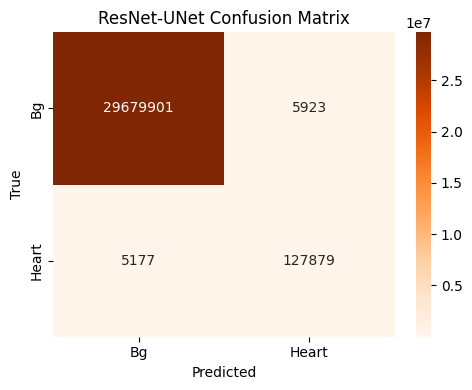

In [ ]:
resnet_results, resnet_preds = evaluate_model(resnet_model, X_test, y_test)
print("=== ResNet-UNet Results ===")
for k, v in resnet_results.items():
    if k != 'cm':
        print(f"  {k:10s}: {v:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(resnet_results['cm'], annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bg','Heart'], yticklabels=['Bg','Heart'])
plt.title('ResNet-UNet Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Visualise ResNet-UNet Predictions

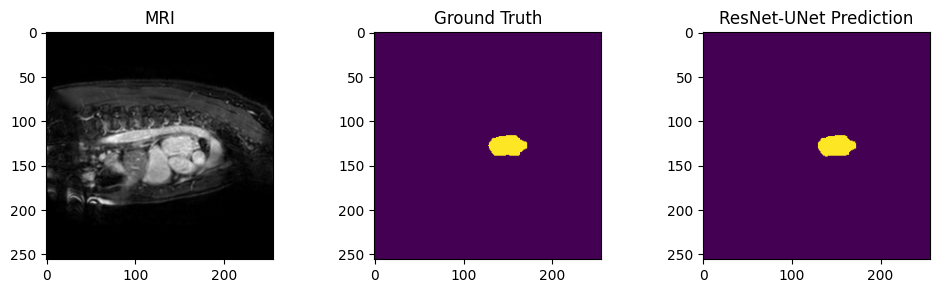

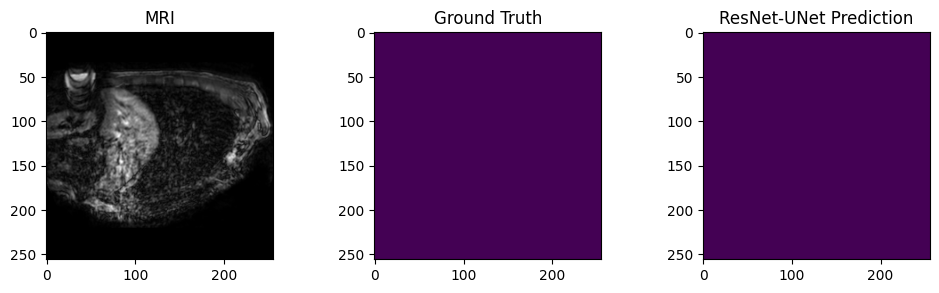

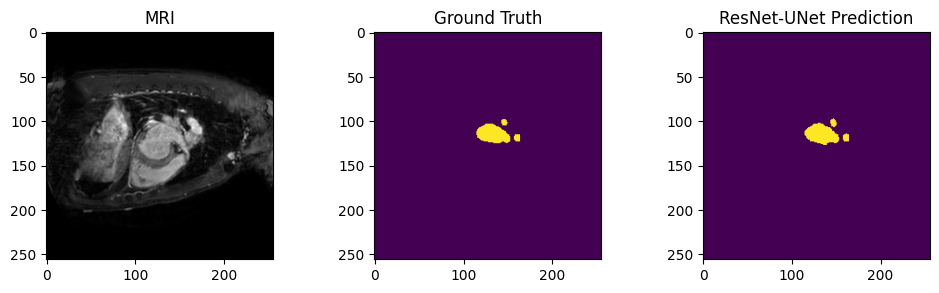

In [ ]:
for i in range(3):
    idx = np.random.randint(0, len(X_test))
    plt.figure(figsize=(10, 3))
    plt.subplot(1,3,1); plt.imshow(X_test[idx].squeeze(), cmap='gray');    plt.title('MRI')
    plt.subplot(1,3,2); plt.imshow(y_test[idx].squeeze());                 plt.title('Ground Truth')
    plt.subplot(1,3,3); plt.imshow(resnet_preds[idx].squeeze());           plt.title('ResNet-UNet Prediction')
    plt.tight_layout(); plt.show()

In [ ]:
import numpy as np

# Select a random index for demonstration, similar to visualization cells
idx = np.random.randint(0, len(X_test))

y_true = y_test[idx]
y_pred = resnet_preds[idx] # Corrected: Use resnet_preds for the predicted mask

# Ensure y_pred is binary, as dice_coef expects binary masks for accurate calculation
y_pred_binary = (y_pred > 0.5).astype(np.float32) # Assuming a threshold of 0.5 for binarization

intersection = np.sum(y_true * y_pred_binary)
dice = (2. * intersection) / (np.sum(y_true) + np.sum(y_pred_binary) + 1e-8) # Added epsilon for stability

print(f"Dice score for image at index {idx}: {dice:.4f}")

Dice score for image at index 345: 0.0000


---
## 11. Model 3 — SegNet
SegNet is an encoder–decoder where the **decoder uses max-pooling indices** (stored from the encoder) to upsample feature maps. This produces sharper boundaries without skip connections and uses less memory than U-Net. Widely used in medical image segmentation.

In [ ]:
def conv_bn_relu(x, filters, n=2):
    """n consecutive Conv → BN → ReLU layers."""
    for _ in range(n):
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
    return x

def build_segnet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # ── Encoder ──────────────────────────────────────────────────────────────
    e1 = conv_bn_relu(inputs, 64, 2);  p1 = layers.MaxPooling2D()(e1)
    e2 = conv_bn_relu(p1,     128, 2); p2 = layers.MaxPooling2D()(e2)
    e3 = conv_bn_relu(p2,     256, 3); p3 = layers.MaxPooling2D()(e3)
    e4 = conv_bn_relu(p3,     512, 3); p4 = layers.MaxPooling2D()(e4)

    # ── Decoder (UpSampling2D approximates max-pooling unpooling) ────────────
    d4 = layers.UpSampling2D()(p4); d4 = conv_bn_relu(d4, 512, 3)
    d3 = layers.UpSampling2D()(d4); d3 = conv_bn_relu(d3, 256, 3)
    d2 = layers.UpSampling2D()(d3); d2 = conv_bn_relu(d2, 128, 2)
    d1 = layers.UpSampling2D()(d2); d1 = conv_bn_relu(d1,  64, 2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d1)
    return models.Model(inputs, outputs, name='SegNet')

segnet_model = build_segnet()
segnet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss=bce_dice_loss, metrics=[dice_coef])
segnet_model.summary()

Model: "SegNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 64, 64, 256)    │       590,08

 Total params: 17,648,513 (67.32 MB)

 Trainable params: 17,637,761 (67.28 MB)

 Non-trainable params: 10,752 (42.00 KB)

### Train SegNet

In [ ]:
segnet_history = segnet_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 189s 676ms/step - dice_coef: 0.0797 - loss: 1.0460 - val_dice_coef: 0.0080 - val_loss: 1.0969
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 99s 485ms/step - dice_coef: 0.1434 - loss: 0.9132 - val_dice_coef: 0.0083 - val_loss: 1.0385
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 99s 485ms/step - dice_coef: 0.2205 - loss: 0.8152 - val_dice_coef: 0.0049 - val_loss: 1.0420
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 99s 485ms/step - dice_coef: 0.3285 - loss: 0.6949 - val_dice_coef: 0.3741 - val_loss: 0.6555
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 99s 485ms/step - dice_coef: 0.4806 - loss: 0.5320 - val_dice_coef: 0.2441 - val_loss: 0.7828
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 100s 486ms/step - dice_coef: 0.6064 - loss: 0.4004 - val_dice_coef: 0.6217 - val_loss: 0.3865
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 99s 485ms/step - dice_coef: 0.7022 - loss: 0.3047 - val_dice_coef: 0.5621 - val_loss: 0.4482
Epoch 8/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 100s 485ms/step - dice_coef

### Evaluate SegNet

=== SegNet Results ===
  dice      : 0.9216
  iou       : 0.8877
  accuracy  : 0.9995
  precision : 0.9465
  recall    : 0.9494
  f1        : 0.9479


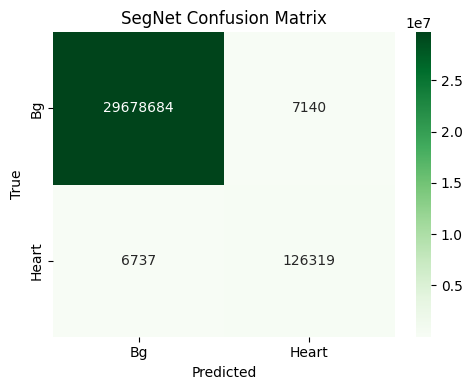

In [ ]:
segnet_results, segnet_preds = evaluate_model(segnet_model, X_test, y_test)
print("=== SegNet Results ===")
for k, v in segnet_results.items():
    if k != 'cm':
        print(f"  {k:10s}: {v:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(segnet_results['cm'], annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bg','Heart'], yticklabels=['Bg','Heart'])
plt.title('SegNet Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Visualise SegNet Predictions

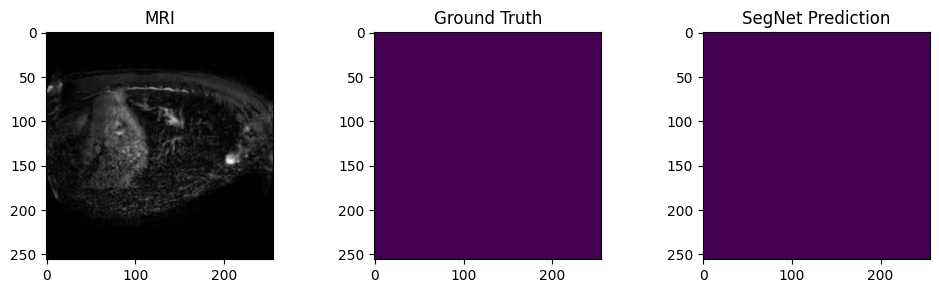

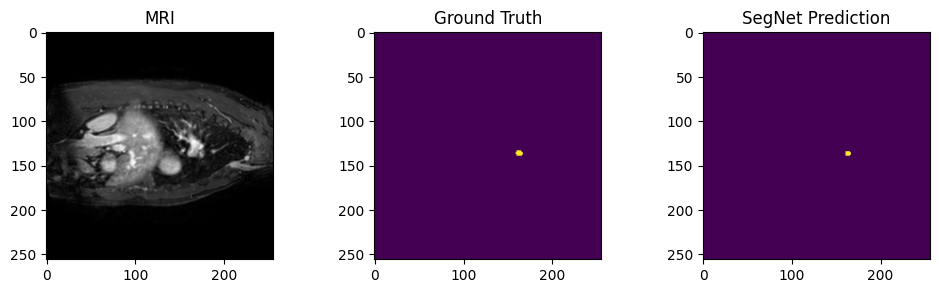

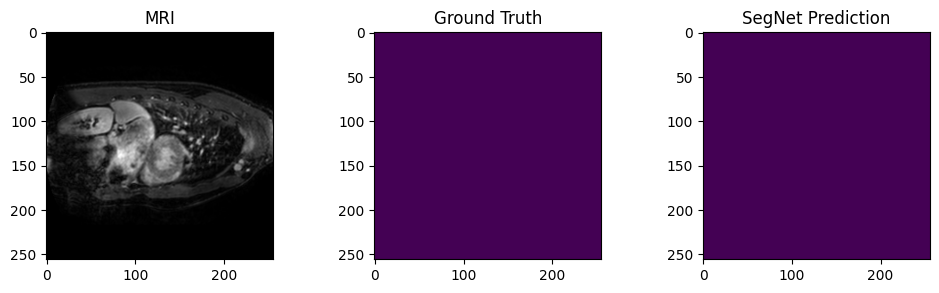

In [ ]:
for i in range(3):
    idx = np.random.randint(0, len(X_test))
    plt.figure(figsize=(10, 3))
    plt.subplot(1,3,1); plt.imshow(X_test[idx].squeeze(), cmap='gray');  plt.title('MRI')
    plt.subplot(1,3,2); plt.imshow(y_test[idx].squeeze());               plt.title('Ground Truth')
    plt.subplot(1,3,3); plt.imshow(segnet_preds[idx].squeeze());         plt.title('SegNet Prediction')
    plt.tight_layout(); plt.show()

In [ ]:
import numpy as np

# Select a random index for demonstration, similar to visualization cells
idx = np.random.randint(0, len(X_test))

y_true = y_test[idx]
y_pred = segnet_preds[idx] # Corrected: Use segnet_preds for the predicted mask

# Ensure y_pred is binary, as dice_coef expects binary masks for accurate calculation
y_pred_binary = (y_pred > 0.5).astype(np.float32) # Assuming a threshold of 0.5 for binarization

intersection = np.sum(y_true * y_pred_binary)
dice = (2. * intersection) / (np.sum(y_true) + np.sum(y_pred_binary) + 1e-8) # Added epsilon for stability

print(f"Dice score for image at index {idx}: {dice:.4f}")

Dice score for image at index 316: 0.8398


---
## 12. Model 4 — DeepLabV3+ (Baseline) vs DeepLabV3+ with Transformer Attention
We train **two** DeepLabV3+ variants back-to-back so their metrics can be directly compared:

| Variant | Description |
|---------|-------------|
| **DeepLabV3+ Baseline** | Original ASPP, no attention |
| **DeepLabV3+ + Attention** | SE Channel Attention + CBAM Spatial Attention + Transformer MHSA inside ASPP |

This lets us measure exactly how much the attention modules improve Dice, IoU, Precision, Recall & F1.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# DeepLabV3+ with Transformer Attention Modules
# Components:
#   1. Channel Attention  (Squeeze-and-Excitation block)
#   2. Spatial Attention  (CBAM-style)
#   3. Multi-Head Self-Attention (Transformer block inside ASPP)
# ═══════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────
# 1. Channel Attention — Squeeze-and-Excitation (SE) Block
# ─────────────────────────────────────────────────────────────────────────────
def channel_attention(x, reduction_ratio=16):
    """
    Squeeze-and-Excitation (SE) block.
    Squeezes spatial dimensions via GlobalAvgPool, then excites
    channel-wise with two FC layers, producing a channel weighting vector.
    """
    channels = x.shape[-1]
    # Squeeze: aggregate spatial info
    se = layers.GlobalAveragePooling2D()(x)                      # (B, C)
    # Excitation: learn channel weights
    se = layers.Dense(max(channels // reduction_ratio, 8), activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)         # (B, C)
    se = layers.Reshape((1, 1, channels))(se)                     # (B, 1, 1, C)
    return layers.Multiply()([x, se])                             # broadcast multiply


# ─────────────────────────────────────────────────────────────────────────────
# 2. Spatial Attention — CBAM-style
# ─────────────────────────────────────────────────────────────────────────────
def spatial_attention(x):
    """
    CBAM Spatial Attention:
    Computes avg-pool and max-pool along channel axis, concatenates them,
    applies a 7×7 conv to produce a 2-D attention map.
    """
    avg_pool = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True))(x)
    max_pool = layers.Lambda(lambda t: tf.reduce_max(t,  axis=-1, keepdims=True))(x)
    concat   = layers.Concatenate(axis=-1)([avg_pool, max_pool])  # (B, H, W, 2)
    attn_map = layers.Conv2D(1, 7, padding='same', activation='sigmoid')(concat)
    return layers.Multiply()([x, attn_map])


# ─────────────────────────────────────────────────────────────────────────────
# 3. Transformer Self-Attention block (Multi-Head)
# ─────────────────────────────────────────────────────────────────────────────
def transformer_attention_block(x, num_heads=8, key_dim=32):
    """
    Applies Multi-Head Self-Attention (MHSA) to spatial feature maps.
    Reshapes (H, W, C) → (H*W, C), runs MHA, then reshapes back.
    Includes a residual connection and LayerNorm (pre-norm style).
    """
    B, H, W, C = x.shape[0], x.shape[1], x.shape[2], x.shape[3]

    # Flatten spatial dims: (B, H, W, C) → (B, H*W, C)
    seq_len = H * W
    x_flat = layers.Reshape((seq_len, C))(x)

    # LayerNorm before attention (pre-norm)
    x_norm = layers.LayerNormalization(epsilon=1e-6)(x_flat)

    # Multi-Head Self-Attention
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=0.1
    )(x_norm, x_norm)                                             # (B, seq_len, C)

    # Residual connection
    x_flat = layers.Add()([x_flat, attn_out])

    # Feed-Forward sublayer (FFN) with residual
    x_norm2  = layers.LayerNormalization(epsilon=1e-6)(x_flat)
    ffn_out  = layers.Dense(C * 2, activation='gelu')(x_norm2)
    ffn_out  = layers.Dropout(0.1)(ffn_out)
    ffn_out  = layers.Dense(C)(ffn_out)
    x_flat   = layers.Add()([x_flat, ffn_out])

    # Reshape back to spatial: (B, H*W, C) → (B, H, W, C)
    x_out = layers.Reshape((H, W, C))(x_flat)
    return x_out


# ─────────────────────────────────────────────────────────────────────────────
# 4. ASPP block with integrated Transformer attention
# ─────────────────────────────────────────────────────────────────────────────
def aspp_attention_block(x, filters=256):
    """
    Atrous Spatial Pyramid Pooling (ASPP) with Transformer self-attention
    inserted at the bottleneck before final projection.
    """
    H, W = x.shape[1], x.shape[2]

    # Global context branch
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Reshape((1, 1, gap.shape[-1]))(gap)
    gap = layers.Conv2D(filters, 1, padding='same', activation='relu')(gap)
    gap = layers.UpSampling2D(size=(H, W), interpolation='bilinear')(gap)

    # Atrous convolutions at multiple scales
    a1  = layers.Conv2D(filters, 1, dilation_rate=1,  padding='same', activation='relu')(x)
    a6  = layers.Conv2D(filters, 3, dilation_rate=6,  padding='same', activation='relu')(x)
    a12 = layers.Conv2D(filters, 3, dilation_rate=12, padding='same', activation='relu')(x)
    a18 = layers.Conv2D(filters, 3, dilation_rate=18, padding='same', activation='relu')(x)

    # Concatenate all branches
    out = layers.concatenate([gap, a1, a6, a12, a18])            # (B, H, W, 5*filters)

    # Project to `filters` channels
    out = layers.Conv2D(filters, 1, activation='relu')(out)
    out = layers.BatchNormalization()(out)

    # ── Attention augmentation ───────────────────────────────────────────────
    # Channel attention: recalibrate which channels matter most
    out = channel_attention(out, reduction_ratio=16)
    # Spatial attention: highlight important spatial regions
    out = spatial_attention(out)
    # Transformer self-attention: global context at 32×32 resolution
    out = transformer_attention_block(out, num_heads=8, key_dim=32)

    return out


# ─────────────────────────────────────────────────────────────────────────────
# 5. Full DeepLabV3+ with Attention
# ─────────────────────────────────────────────────────────────────────────────
def build_deeplabv3plus_attention(input_shape=(256, 256, 1)):
    """
    DeepLabV3+ enhanced with:
      - SE Channel Attention after each encoder stage
      - CBAM Spatial Attention after each encoder stage
      - Transformer (MHSA + FFN) inside ASPP
      - Channel + Spatial attention again in the decoder
    """
    inputs = layers.Input(input_shape)

    # ── Encoder ──────────────────────────────────────────────────────────────
    # Stage 1: stride-2  256 → 128
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = channel_attention(x)                    # SE after stage 1
    x = spatial_attention(x)                    # Spatial after stage 1

    # Stage 2: stride-2  128 → 64
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = channel_attention(x)                    # SE after stage 2
    x = spatial_attention(x)                    # Spatial after stage 2

    # Low-level features (64×64, 48 ch) for decoder shortcut
    low_level = layers.Conv2D(48, 1, activation='relu')(x)

    # Stage 3: stride-2  64 → 32
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # ── ASPP + Transformer attention (at 32×32) ───────────────────────────────
    x = aspp_attention_block(x, filters=256)

    # ── Decoder ──────────────────────────────────────────────────────────────
    # Upsample ASPP output: 32 → 128
    x = layers.UpSampling2D(size=(4, 4), interpolation='bilinear')(x)
    x = layers.Conv2D(256, 1, activation='relu')(x)

    # Merge with low-level features (upsample low_level 64 → 128)
    upsampled_low = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(low_level)
    x = layers.concatenate([x, upsampled_low])

    # Refine
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    # Decoder attention: re-focus on heart region
    x = channel_attention(x)
    x = spatial_attention(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Final upsample: 128 → 256
    x = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(x)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)

    return models.Model(inputs, outputs, name='DeepLabV3Plus_Attention')


# Build & compile
deeplabv3_model = build_deeplabv3plus_attention()
deeplabv3_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coef]
)
deeplabv3_model.summary()


Model: "DeepLabV3Plus_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 128, 128,  │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_55[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        264 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        288 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128, 128,  │          0 │ multiply[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128, 128,  │          0 │ multiply[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 128, 128,  │          0 │ lambda[0][0],     │
│ (Concatenate)       │ 2)                │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 128, 128,  │         99 │ concatenate_6[0]… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 128, 128,  │          0 │ multiply[0][0],   │
│ (Multiply)          │ 32)               │            │ conv2d_56[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 64, 64,    │     18,496 │ multiply_1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_57[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │        576 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,528,589 (17.28 MB)

 Trainable params: 4,526,093 (17.27 MB)

 Non-trainable params: 2,496 (9.75 KB)

### 12a. Baseline DeepLabV3+ (no attention) — for comparison

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# DeepLabV3+ BASELINE (original — no attention modules)
# Kept identical to the original paper's lightweight implementation
# so the comparison is fair.
# ═══════════════════════════════════════════════════════════════════════════════

def aspp_block_baseline(x, filters=256):
    """Original ASPP — no attention."""
    H, W = x.shape[1], x.shape[2]
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Reshape((1, 1, gap.shape[-1]))(gap)
    gap = layers.Conv2D(filters, 1, padding='same', activation='relu')(gap)
    gap = layers.UpSampling2D(size=(H, W), interpolation='bilinear')(gap)
    a1  = layers.Conv2D(filters, 1, dilation_rate=1,  padding='same', activation='relu')(x)
    a6  = layers.Conv2D(filters, 3, dilation_rate=6,  padding='same', activation='relu')(x)
    a12 = layers.Conv2D(filters, 3, dilation_rate=12, padding='same', activation='relu')(x)
    a18 = layers.Conv2D(filters, 3, dilation_rate=18, padding='same', activation='relu')(x)
    out = layers.concatenate([gap, a1, a6, a12, a18])
    out = layers.Conv2D(filters, 1, activation='relu')(out)
    out = layers.BatchNormalization()(out)
    return out

def build_deeplabv3plus_baseline(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    low_level = layers.Conv2D(48, 1, activation='relu')(x)
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = aspp_block_baseline(x, filters=256)
    x = layers.UpSampling2D(size=(4, 4), interpolation='bilinear')(x)
    x = layers.Conv2D(256, 1, activation='relu')(x)
    upsampled_low = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(low_level)
    x = layers.concatenate([x, upsampled_low])
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(x)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name='DeepLabV3Plus_Baseline')

deeplabv3_baseline = build_deeplabv3plus_baseline()
deeplabv3_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=bce_dice_loss, metrics=[dice_coef]
)
print("✅ Baseline built —", deeplabv3_baseline.count_params(), "params")

# Attention model (built in previous cell)
print("✅ Attention model —", deeplabv3_model.count_params(), "params")


✅ Baseline built — 3982513 params
✅ Attention model — 4528589 params


### 12b. Train Both DeepLabV3+ Variants

In [ ]:
# ─── Train DeepLabV3+ Baseline ────────────────────────────────────────────────
print("\n🚀 Training DeepLabV3+ Baseline...")
baseline_history = deeplabv3_baseline.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

# ─── Train DeepLabV3+ + Attention ─────────────────────────────────────────────
print("\n🚀 Training DeepLabV3+ + Transformer Attention...")
attention_history = deeplabv3_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)



🚀 Training DeepLabV3+ Baseline...
Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 160s 589ms/step - dice_coef: 0.0204 - loss: 1.5308 - val_dice_coef: 0.0078 - val_loss: 1.2828
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 135s 427ms/step - dice_coef: 0.0340 - loss: 1.2754 - val_dice_coef: 0.0084 - val_loss: 1.0967
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 87s 424ms/step - dice_coef: 0.0585 - loss: 1.1105 - val_dice_coef: 0.0935 - val_loss: 0.9827
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 87s 425ms/step - dice_coef: 0.1174 - loss: 0.9688 - val_dice_coef: 0.2141 - val_loss: 0.8164
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 87s 424ms/step - dice_coef: 0.2766 - loss: 0.7641 - val_dice_coef: 0.5961 - val_loss: 0.4390
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 87s 423ms/step - dice_coef: 0.6003 - loss: 0.4206 - val_dice_coef: 0.8212 - val_loss: 0.1896
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 87s 423ms/step - dice_coef: 0.8169 - loss: 0.1935 - val_dice_coef: 0.8939 - val_loss: 0.1162
Epoch 8/30
205/205 ━━━━━━━━━━━━━

### 12c. Evaluate Both Variants

In [ ]:
# ─── Evaluate both variants ───────────────────────────────────────────────────
baseline_results,  baseline_preds  = evaluate_model(deeplabv3_baseline, X_test, y_test)
attention_results, attention_preds = evaluate_model(deeplabv3_model,    X_test, y_test)

print("\n=== DeepLabV3+ Baseline ===")
for k, v in baseline_results.items():
    if k != 'cm': print(f"  {k:10s}: {v:.4f}")

print("\n=== DeepLabV3+ + Attention ===")
for k, v in attention_results.items():
    if k != 'cm': print(f"  {k:10s}: {v:.4f}")

# Delta
print("\n=== Δ Improvement (Attention − Baseline) ===")
metrics_keys = ['dice','iou','accuracy','precision','recall','f1']
for k in metrics_keys:
    delta = attention_results[k] - baseline_results[k]
    arrow = "▲" if delta >= 0 else "▼"
    print(f"  {k:10s}: {arrow} {abs(delta):.4f}")



=== DeepLabV3+ Baseline ===
  dice      : 0.9428
  iou       : 0.9132
  accuracy  : 0.9996
  precision : 0.9624
  recall    : 0.9565
  f1        : 0.9594

=== DeepLabV3+ + Attention ===
  dice      : 0.9422
  iou       : 0.9111
  accuracy  : 0.9996
  precision : 0.9565
  recall    : 0.9546
  f1        : 0.9555

=== Δ Improvement (Attention − Baseline) ===
  dice      : ▼ 0.0006
  iou       : ▼ 0.0020
  accuracy  : ▼ 0.0000
  precision : ▼ 0.0059
  recall    : ▼ 0.0019
  f1        : ▼ 0.0039


---
## 12d. 📊 DeepLabV3+ Attention Impact — Full Visualization Suite
Six plots covering: grouped bars, delta bars, radar chart, training curves, prediction grid, and confusion matrices.

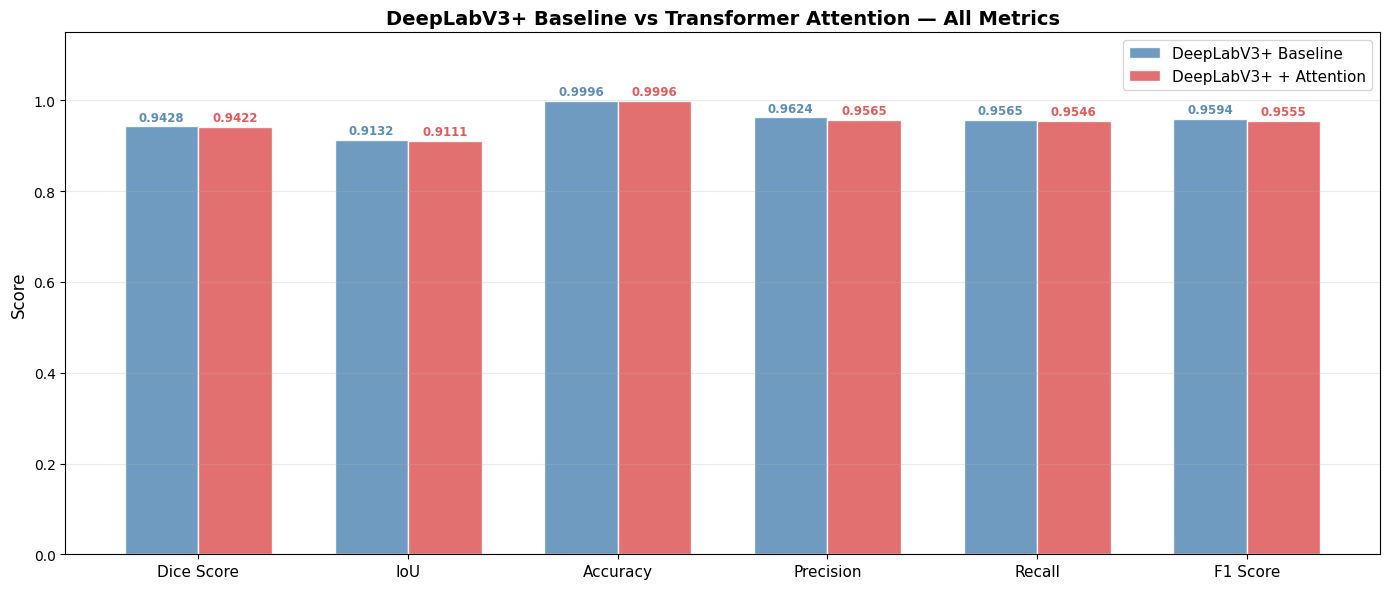

Saved: deeplabv3_baseline_vs_attention_bar.png


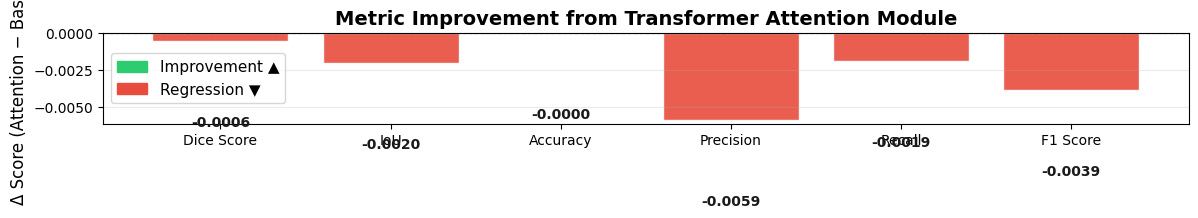

Saved: deeplabv3_delta_improvement.png


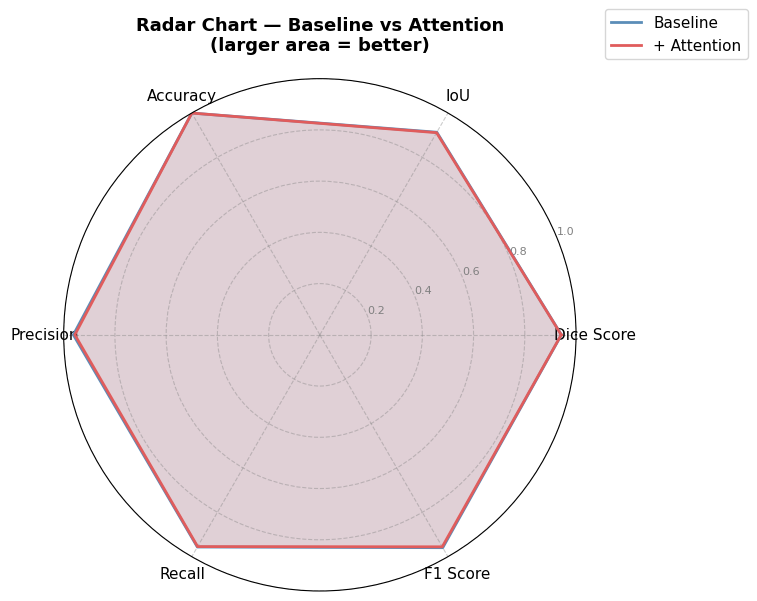

Saved: deeplabv3_radar.png


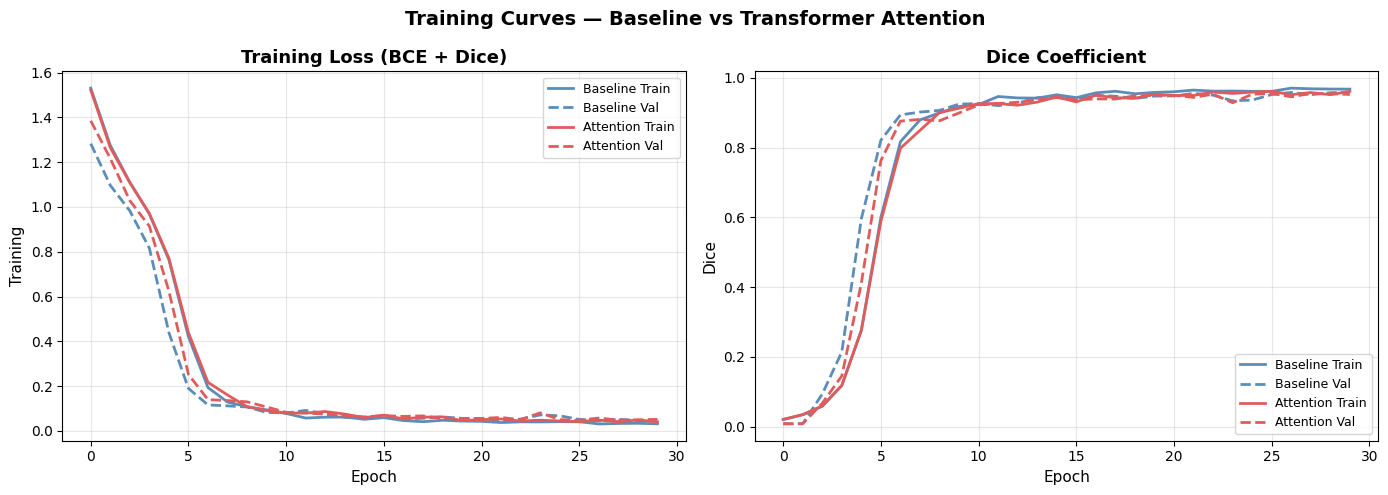

Saved: deeplabv3_training_curves.png


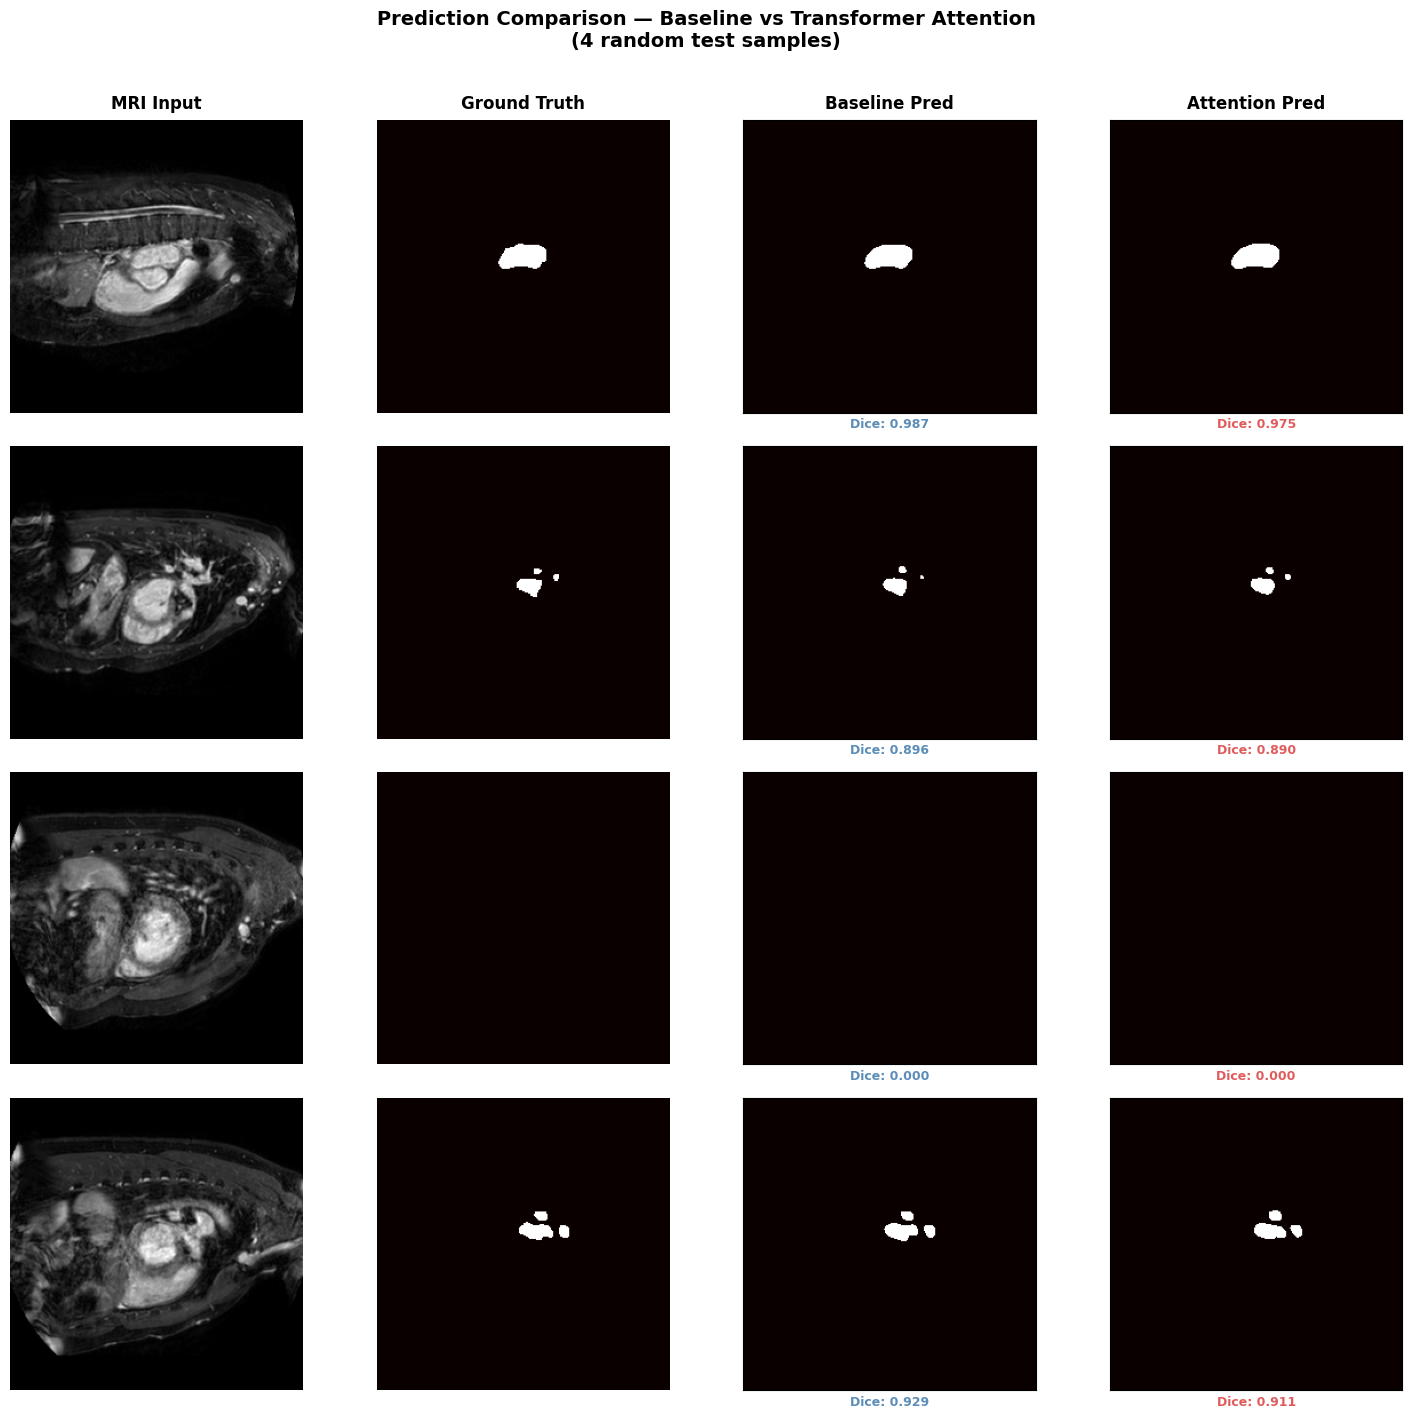

Saved: deeplabv3_prediction_grid.png


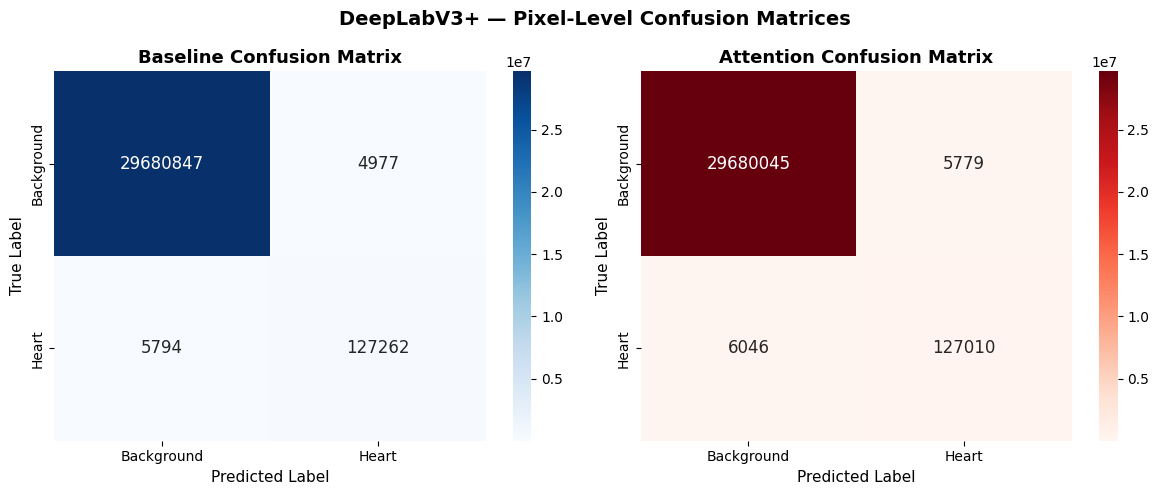

Saved: deeplabv3_confusion_matrices.png


In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

metrics_keys   = ['dice', 'iou', 'accuracy', 'precision', 'recall', 'f1']
metrics_labels = ['Dice Score', 'IoU', 'Accuracy', 'Precision', 'Recall', 'F1 Score']

baseline_vals  = [baseline_results[m]  for m in metrics_keys]
attention_vals = [attention_results[m] for m in metrics_keys]
deltas         = [a - b for a, b in zip(attention_vals, baseline_vals)]

BL_COLOR  = '#5B8DB8'   # steel blue  — baseline
ATT_COLOR = '#E05C5C'   # warm red    — attention
POS_COLOR = '#2ECC71'   # green       — positive delta
NEG_COLOR = '#E74C3C'   # red         — negative delta

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Grouped bar: Baseline vs Attention across all metrics
# ════════════════════════════════════════════════════════════════════════════
x     = np.arange(len(metrics_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, baseline_vals,  width, label='DeepLabV3+ Baseline',  color=BL_COLOR,  alpha=0.88, edgecolor='white')
bars2 = ax.bar(x + width/2, attention_vals, width, label='DeepLabV3+ + Attention', color=ATT_COLOR, alpha=0.88, edgecolor='white')

for bar, val in zip(bars1, baseline_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8.5, color=BL_COLOR, fontweight='bold')
for bar, val in zip(bars2, attention_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8.5, color=ATT_COLOR, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('DeepLabV3+ Baseline vs Transformer Attention — All Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('deeplabv3_baseline_vs_attention_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: deeplabv3_baseline_vs_attention_bar.png")

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Delta bar chart (improvement per metric)
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [POS_COLOR if d >= 0 else NEG_COLOR for d in deltas]
bars = ax.bar(metrics_labels, deltas, color=bar_colors, edgecolor='white', alpha=0.9)

for bar, d in zip(bars, deltas):
    ypos = bar.get_height() + 0.001 if d >= 0 else bar.get_height() - 0.006
    ax.text(bar.get_x()+bar.get_width()/2, ypos,
            f'{d:+.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold',
            color='#1a1a1a')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Δ Score (Attention − Baseline)', fontsize=12)
ax.set_title('Metric Improvement from Transformer Attention Module', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
pos_patch = mpatches.Patch(color=POS_COLOR, label='Improvement ▲')
neg_patch = mpatches.Patch(color=NEG_COLOR, label='Regression ▼')
ax.legend(handles=[pos_patch, neg_patch], fontsize=11)
plt.tight_layout()
plt.savefig('deeplabv3_delta_improvement.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: deeplabv3_delta_improvement.png")

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Radar / Spider chart
# ════════════════════════════════════════════════════════════════════════════
from matplotlib.patches import FancyArrowPatch
import matplotlib.cm as cm

N      = len(metrics_keys)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

bl_vals  = baseline_vals  + baseline_vals[:1]
att_vals = attention_vals + attention_vals[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, bl_vals,  color=BL_COLOR,  linewidth=2, linestyle='solid',  label='Baseline')
ax.fill(angles, bl_vals,  color=BL_COLOR,  alpha=0.18)
ax.plot(angles, att_vals, color=ATT_COLOR, linewidth=2, linestyle='solid',  label='+ Attention')
ax.fill(angles, att_vals, color=ATT_COLOR, alpha=0.18)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8, color='grey')
ax.set_title('Radar Chart — Baseline vs Attention\n(larger area = better)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.grid(color='grey', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('deeplabv3_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: deeplabv3_radar.png")

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Training loss curves: Baseline vs Attention
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, title in zip(axes,
                           ['loss', 'dice_coef'],
                           ['Training Loss (BCE + Dice)', 'Dice Coefficient']):
    ax.plot(baseline_history.history[key],       color=BL_COLOR,  lw=2, label='Baseline Train')
    ax.plot(baseline_history.history[f'val_{key}'], color=BL_COLOR, lw=2, linestyle='--', label='Baseline Val')
    ax.plot(attention_history.history[key],      color=ATT_COLOR, lw=2, label='Attention Train')
    ax.plot(attention_history.history[f'val_{key}'], color=ATT_COLOR, lw=2, linestyle='--', label='Attention Val')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(title.split(' ')[0], fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Training Curves — Baseline vs Transformer Attention', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('deeplabv3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: deeplabv3_training_curves.png")

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — Side-by-side prediction samples: Input | GT | Baseline | Attention
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(4, 4, figsize=(15, 14))
col_titles = ['MRI Input', 'Ground Truth', 'Baseline Pred', 'Attention Pred']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold', pad=8)

for row in range(4):
    idx = np.random.randint(0, len(X_test))
    axes[row, 0].imshow(X_test[idx].squeeze(), cmap='gray')
    axes[row, 1].imshow(y_test[idx].squeeze(), cmap='hot')
    axes[row, 2].imshow(baseline_preds[idx].squeeze(),  cmap='hot')
    axes[row, 3].imshow(attention_preds[idx].squeeze(), cmap='hot')

    # Per-sample dice for both
    yt = y_test[idx].flatten()
    yb = baseline_preds[idx].flatten()
    ya = attention_preds[idx].flatten()
    db = (2*np.sum(yt*yb))/(np.sum(yt)+np.sum(yb)+1e-8)
    da = (2*np.sum(yt*ya))/(np.sum(yt)+np.sum(ya)+1e-8)
    axes[row, 2].set_xlabel(f'Dice: {db:.3f}', fontsize=9, color=BL_COLOR, fontweight='bold')
    axes[row, 3].set_xlabel(f'Dice: {da:.3f}', fontsize=9, color=ATT_COLOR, fontweight='bold')

    for col in range(4):
        axes[row, col].axis('off') if col < 2 else None
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

plt.suptitle('Prediction Comparison — Baseline vs Transformer Attention\n(4 random test samples)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('deeplabv3_prediction_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: deeplabv3_prediction_grid.png")

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 6 — Confusion Matrices side by side
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, res, title, cmap in zip(
        axes,
        [baseline_results, attention_results],
        ['Baseline Confusion Matrix', 'Attention Confusion Matrix'],
        ['Blues', 'Reds']):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Background','Heart'], yticklabels=['Background','Heart'],
                annot_kws={'size': 12})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
plt.suptitle('DeepLabV3+ — Pixel-Level Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('deeplabv3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: deeplabv3_confusion_matrices.png")


### 12e. Numeric Summary — Baseline vs Attention

In [ ]:
# ─── Numeric Summary Table ────────────────────────────────────────────────────
import pandas as pd

metrics_keys   = ['dice', 'iou', 'accuracy', 'precision', 'recall', 'f1']
metrics_labels = ['Dice', 'IoU', 'Accuracy', 'Precision', 'Recall', 'F1']

rows = []
for label, res in [('DeepLabV3+ Baseline', baseline_results),
                   ('DeepLabV3+ + Attention', attention_results)]:
    row = {'Model': label}
    row.update({ml: f"{res[mk]:.4f}" for mk, ml in zip(metrics_keys, metrics_labels)})
    rows.append(row)

# Delta row
delta_row = {'Model': 'Δ (Attn − Base)'}
for mk, ml in zip(metrics_keys, metrics_labels):
    d = attention_results[mk] - baseline_results[mk]
    delta_row[ml] = f"{'+'if d>=0 else ''}{d:.4f}"
rows.append(delta_row)

df = pd.DataFrame(rows)
print("\n" + "="*75)
print(df.to_string(index=False))
print("="*75)

best_by_dice = 'DeepLabV3+ + Attention' if attention_results['dice'] > baseline_results['dice'] else 'DeepLabV3+ Baseline'
print(f"\n🏆  Better Dice Score : {best_by_dice}")
gain = attention_results['dice'] - baseline_results['dice']
print(f"    Absolute gain     : {gain:+.4f}  ({gain/baseline_results['dice']*100:+.2f}%)")



                 Model    Dice     IoU Accuracy Precision  Recall      F1
   DeepLabV3+ Baseline  0.9428  0.9132   0.9996    0.9624  0.9565  0.9594
DeepLabV3+ + Attention  0.9422  0.9111   0.9996    0.9565  0.9546  0.9555
       Δ (Attn − Base) -0.0006 -0.0020  -0.0000   -0.0059 -0.0019 -0.0039

🏆  Better Dice Score : DeepLabV3+ Baseline
    Absolute gain     : -0.0006  (-0.06%)


### Train DeepLabV3+

In [ ]:
# Training for this variant is handled in cell 12b above.
# deeplabv3_history alias kept for any downstream references.
deeplabv3_history = attention_history  # alias
print('deeplabv3_history aliased to attention_history ✓')

deeplabv3_history aliased to attention_history ✓


### Evaluate DeepLabV3+

=== DeepLabV3+ Results ===
  dice      : 0.9422
  iou       : 0.9111
  accuracy  : 0.9996
  precision : 0.9565
  recall    : 0.9546
  f1        : 0.9555


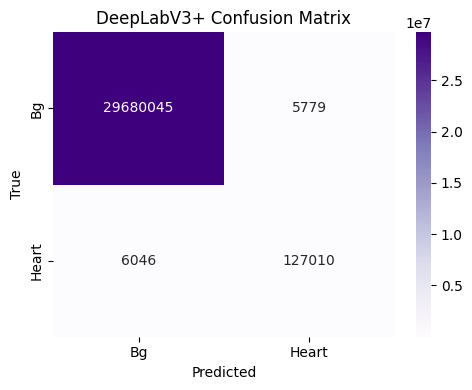

In [ ]:
deeplabv3_results, deeplabv3_preds = evaluate_model(deeplabv3_model, X_test, y_test)
print("=== DeepLabV3+ Results ===")
for k, v in deeplabv3_results.items():
    if k != 'cm':
        print(f"  {k:10s}: {v:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(deeplabv3_results['cm'], annot=True, fmt='d', cmap='Purples',
            xticklabels=['Bg','Heart'], yticklabels=['Bg','Heart'])
plt.title('DeepLabV3+ Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Visualise DeepLabV3+ Predictions

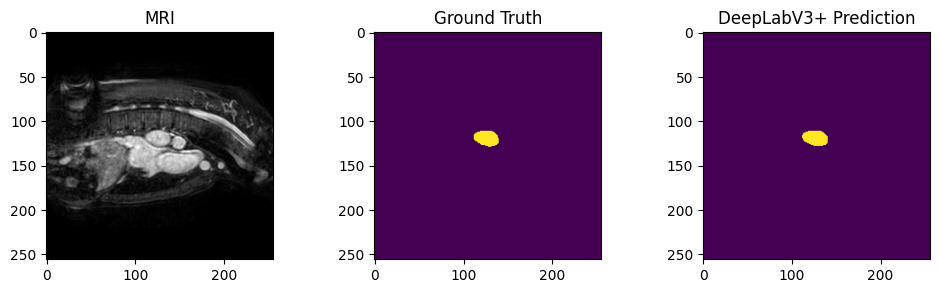

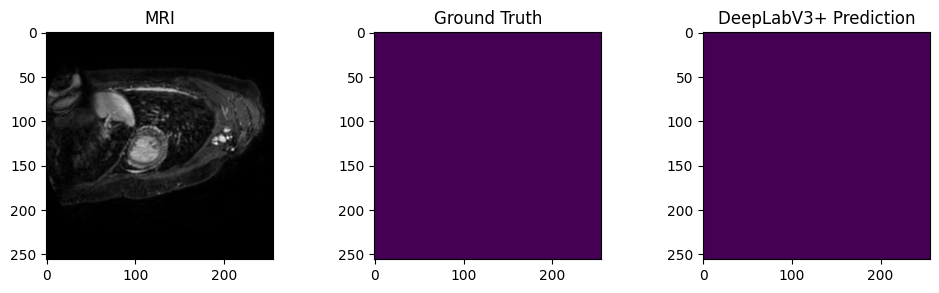

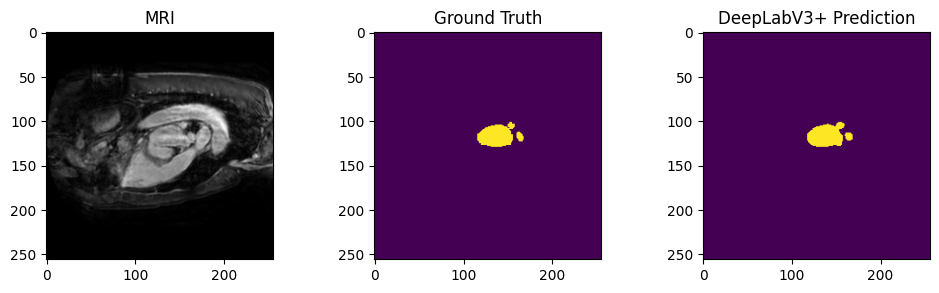

In [ ]:
for i in range(3):
    idx = np.random.randint(0, len(X_test))
    plt.figure(figsize=(10, 3))
    plt.subplot(1,3,1); plt.imshow(X_test[idx].squeeze(), cmap='gray');      plt.title('MRI')
    plt.subplot(1,3,2); plt.imshow(y_test[idx].squeeze());                   plt.title('Ground Truth')
    plt.subplot(1,3,3); plt.imshow(deeplabv3_preds[idx].squeeze());          plt.title('DeepLabV3+ Prediction')
    plt.tight_layout(); plt.show()

In [ ]:
import numpy as np

# Select a random index for demonstration, similar to visualization cells
idx = np.random.randint(0, len(X_test))

y_true = y_test[idx]
y_pred = deeplabv3_preds[idx] # Corrected: Use deeplabv3_preds for the predicted mask

# Ensure y_pred is binary, as dice_coef expects binary masks for accurate calculation
y_pred_binary = (y_pred > 0.5).astype(np.float32) # Assuming a threshold of 0.5 for binarization

intersection = np.sum(y_true * y_pred_binary)
dice = (2. * intersection) / (np.sum(y_true) + np.sum(y_pred_binary) + 1e-8) # Added epsilon for stability

print(f"Dice score for image at index {idx}: {dice:.4f}")

Dice score for image at index 320: 0.9671


---
## 13. 📊 Model Comparison — Bar Graph
Side-by-side comparison of all four models across **Dice Score, IoU, Accuracy, Precision, Recall, and F1 Score**.

In [ ]:
# ─── Update the master results dict to include the attention DeepLabV3+ ───────
# (replaces the plain 'DeepLabV3+' entry so all downstream charts refresh)
all_results = {
    'U-Net':               unet_results,
    'ResNet-UNet':         resnet_results,
    'SegNet':              segnet_results,
    'DLv3+ Baseline':      baseline_results,
    'DLv3+ + Attention':   attention_results,
}
print("all_results updated with 5 models ✓")


all_results updated with 5 models ✓


## 14. Summary Table & Best Model

In [ ]:
import pandas as pd

rows = []
for name, res in all_results.items():
    rows.append({
        'Model':     name,
        'Dice':      f"{res['dice']:.4f}",
        'IoU':       f"{res['iou']:.4f}",
        'Accuracy':  f"{res['accuracy']:.4f}",
        'Precision': f"{res['precision']:.4f}",
        'Recall':    f"{res['recall']:.4f}",
        'F1':        f"{res['f1']:.4f}",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# Best model by Dice
best = max(all_results, key=lambda m: all_results[m]['dice'])
print(f"\n🏆 Best model by Dice Score: {best}  ({all_results[best]['dice']:.4f})")

best_acc = max(all_results, key=lambda m: all_results[m]['accuracy'])
print(f"🏆 Best model by Accuracy  : {best_acc}  ({all_results[best_acc]['accuracy']:.4f})")

            Model   Dice    IoU Accuracy Precision Recall     F1
            U-Net 0.9099 0.8742   0.9995    0.9385 0.9472 0.9429
      ResNet-UNet 0.9465 0.9160   0.9996    0.9557 0.9611 0.9584
           SegNet 0.9216 0.8877   0.9995    0.9465 0.9494 0.9479
   DLv3+ Baseline 0.9428 0.9132   0.9996    0.9624 0.9565 0.9594
DLv3+ + Attention 0.9422 0.9111   0.9996    0.9565 0.9546 0.9555

🏆 Best model by Dice Score: ResNet-UNet  (0.9465)
🏆 Best model by Accuracy  : DLv3+ Baseline  (0.9996)


## 15. Save All Models

In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/Task02_Heart/Task02_Heart"
MODELS_DIR = os.path.join(DATASET_PATH, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

unet_model.save(os.path.join(MODELS_DIR, 'unet_model.keras'))
resnet_model.save(os.path.join(MODELS_DIR, 'resnet_unet_model.keras'))
segnet_model.save(os.path.join(MODELS_DIR, 'segnet_model.keras'))
deeplabv3_baseline.save(os.path.join(MODELS_DIR, 'deeplabv3plus_baseline.keras'))
deeplabv3_model.save(os.path.join(MODELS_DIR, 'deeplabv3plus_attention.keras'))

print(f"All models saved to {MODELS_DIR}!")

All models saved to /content/drive/MyDrive/Task02_Heart/Task02_Heart/models!


## 16. Download Comparison Charts

In [ ]:
from google.colab import files

for fname in [
    'deeplabv3_baseline_vs_attention_bar.png',
    'deeplabv3_delta_improvement.png',
    'deeplabv3_radar.png',
    'deeplabv3_training_curves.png',
    'deeplabv3_prediction_grid.png',
    'deeplabv3_confusion_matrices.png',
]:
    files.download(fname)
    print(f"Downloaded: {fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: deeplabv3_baseline_vs_attention_bar.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: deeplabv3_prediction_grid.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: deeplabv3_confusion_matrices.png


In [ ]:
import os
import shutil

# Base path (same style as yours)
DATASET_PATH = "/content/drive/MyDrive/Task02_Heart/Task02_Heart"
IMAGES_DIR = os.path.join(DATASET_PATH, "outputs")
os.makedirs(IMAGES_DIR, exist_ok=True)

# Copy images to Drive
image_files = [
    'deeplabv3_baseline_vs_attention_bar.png',
    'deeplabv3_delta_improvement.png',
    'deeplabv3_radar.png',
    'deeplabv3_training_curves.png',
    'deeplabv3_prediction_grid.png',
    'deeplabv3_confusion_matrices.png',
]

for fname in image_files:
    shutil.copy(fname, os.path.join(IMAGES_DIR, fname))

print(f"All images saved to {IMAGES_DIR}!")

All images saved to /content/drive/MyDrive/Task02_Heart/Task02_Heart/outputs!
